### **Latent Space Analysis and Visualisation**

In [1]:
import sys
from typing import Any, NamedTuple

from tqdm import tqdm
import torch
from torch.types import Tensor


class LatentVector(NamedTuple):
    """Latent vector container."""
    vals: Tensor
    lbls: Tensor


def get_size(obj: object, default: Any = -1) -> int:
    """Computes how much memory storage is being used by input obj in [bytes]."""
    return sys.getsizeof(obj, default=default)

In [2]:
#BASEPATH: str = '/home/edoardo/Desktop/MockDataForDMs'
BASEPATH: str = '/mnt/d/MockDataForDMs'

latent_dmap: dict[int, LatentVector] = torch.load(f'{BASEPATH}/latentSpaceContainer.pt', weights_only=False)

print(
    f'Latent Space dmap size: {get_size(latent_dmap)} bytes\n'
    f'Number of epochs registered: {len(latent_dmap)}\n'
    f'Embedded data size: vector = {latent_dmap[0].vals.shape}, lbls = {latent_dmap[0].lbls.shape}\n'
)

# NOTE:
#   - a tensor of shape [E, B, C, H, W] occupies less memory than the latent dict map
#   - when saved though, the 5D tensor occupies x2 space (dmap: ~13.7MB, tensor: ~27  MB)
#   - this has been tested on 5 epochs (TODO: test if for larger # of epochs is the same)

Latent Space dmap size: 224 bytes
Number of epochs registered: 5
Embedded data size: vector = torch.Size([800, 8, 15, 15]), lbls = torch.Size([800])



In [ ]:
from itertools import islice

import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt

import umap


def manage_embedded_data(latent_dmap: dict[int, LatentVector]) -> dict[int, tuple[NDArray, NDArray]]:
    """
    Takes the data in the latent dmap and for each epoch flattens the respective
    embedded vector of shape [B, C, H, W] to a tensor [B, C x H x W], finally
    converting it to a numpy array.
    """
    # use `islice` bc `latent_dmap` could be very large (epochs
    # number + respective tensors with all the latent vectors)
    flattened_dmap: dict[int, NDArray] = {
        epoch: (emb.vals.flatten(1, -1).numpy(), emb.lbls.numpy())
        for epoch, emb in islice(latent_dmap.items(), len(latent_dmap))
    }
    return flattened_dmap


def UMAP_dim_reducer(
    data: NDArray,
    n_neighbors: int,
    min_dist: float,
    n_components: int = 2,
    metric: str = 'euclidean',
    **kwards: Any,
) -> NDArray:
    """
    Reduces the dimensionality of the input data with UMAP.
    NOTE: the fit should be performed on processed data
        * remove NaNs
        * avoid different data scales (e.g., convert features
          into z-scores --# of std from mean-- for comparability).
    """
    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        n_components=n_components,
        min_dist=min_dist,
        metric=metric,
        **kwards,
    )
    embedding = reducer.fit_transform(data)
    return embedding


def plot_latent_space(
    embedding: NDArray,
    title: str | None = None,
    labels: NDArray | None = None,
    labels_dmap: dict[int, 'str'] | None = None,
) -> None:
    """Plots the 2D latent space."""
    plt.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap='Spectral', s=10)
    plt.gca().set_aspect('equal', 'datalim')
    if labels_dmap is not None:
        cbar = plt.colorbar(boundaries=np.arange(len(labels_dmap) + 1) - 0.5)
        cbar.set_ticks(np.arange(len(labels_dmap)), labels=list(labels_dmap.values()))
    if title is not None: plt.title(title, fontsize=12)
    plt.show()
    return

In [4]:
EPOCH: int = 0

np_emb: dict[int, NDArray] = manage_embedded_data(latent_dmap)

epoch_latent_vector, epoch_lbls = np_emb[EPOCH]

In [ ]:
CLASS_NAMES: dict[int, str] = {
    0: 'circle',
    1: 'triangle',
    2: 'square',
    3: 'hexagon',
}

N_NEIGHBORS: int = 15
MIN_DIST: float = 0.1
KWDS : dict[str, Any] = {}

embedding = UMAP_dim_reducer(
    data=epoch_latent_vector,
    n_neighbors=N_NEIGHBORS,
    min_dist=MIN_DIST,
    **KWDS,
)

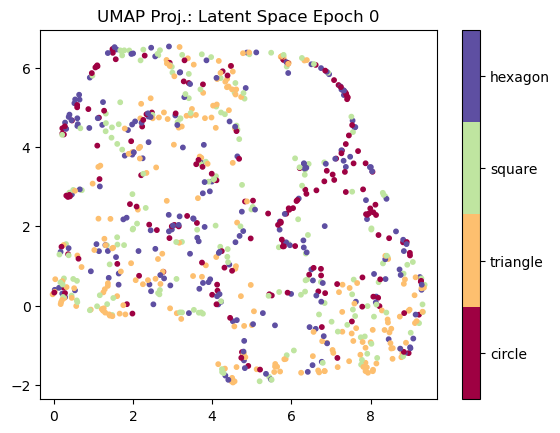

In [ ]:
plot_latent_space(
    embedding=embedding,
    title=f'UMAP Proj.: Latent Space Epoch {EPOCH}',
    labels=epoch_lbls,
    labels_map=CLASS_NAMES,
)

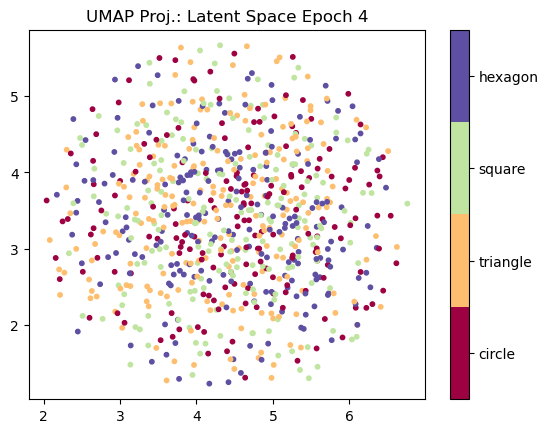

In [10]:
EPOCH: int = 4

epoch_latent_vector, epoch_lbls = np_emb[EPOCH]
embedding = UMAP_dim_reducer(
    data=epoch_latent_vector,
    n_neighbors=N_NEIGHBORS,
    min_dist=MIN_DIST,
    **KWDS,
)
plot_latent_space(
    embedding=embedding,
    title=f'UMAP Proj.: Latent Space Epoch {EPOCH}',
    labels=epoch_lbls,
    labels_map=CLASS_NAMES,
)

In [ ]:
assert False

In [ ]:
import umap.plot as upt

upt.points(embedding)

/home/starfloyd/anaconda3/envs/spark/lib/python3.13/site-packages/umap/plot.py:20: UserWarning: The umap.plot package requires extra plotting libraries to be installed.
    You can install these via pip using

    pip install umap-learn[plot]

    or via conda using

     conda install pandas matplotlib datashader bokeh holoviews colorcet scikit-image
    
  warn(


ImportError: umap.plot requires pandas matplotlib datashader bokeh holoviews scikit-image and colorcet to be installed